Premières lignes du dataset :
   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0 

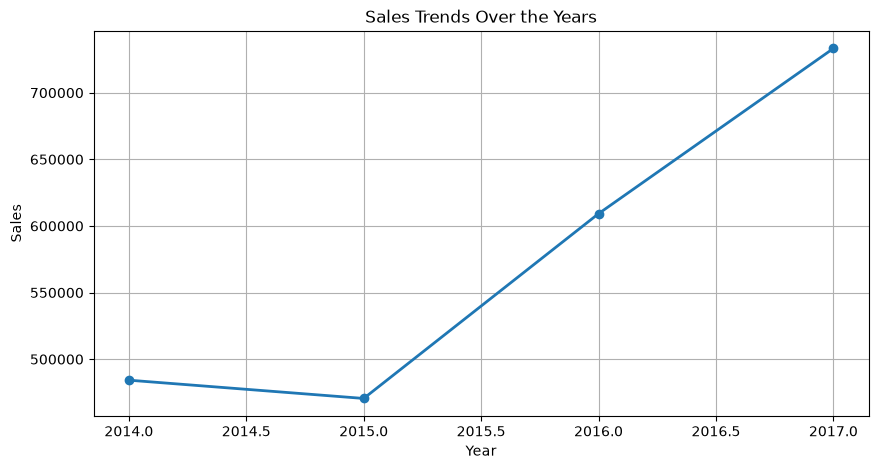

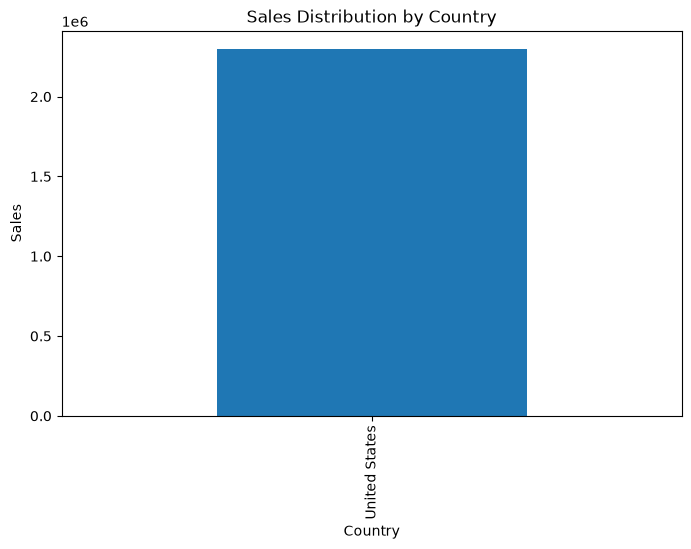

C:\Users\GUE\AppData\Local\Temp\ipykernel_29176\4010571183.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


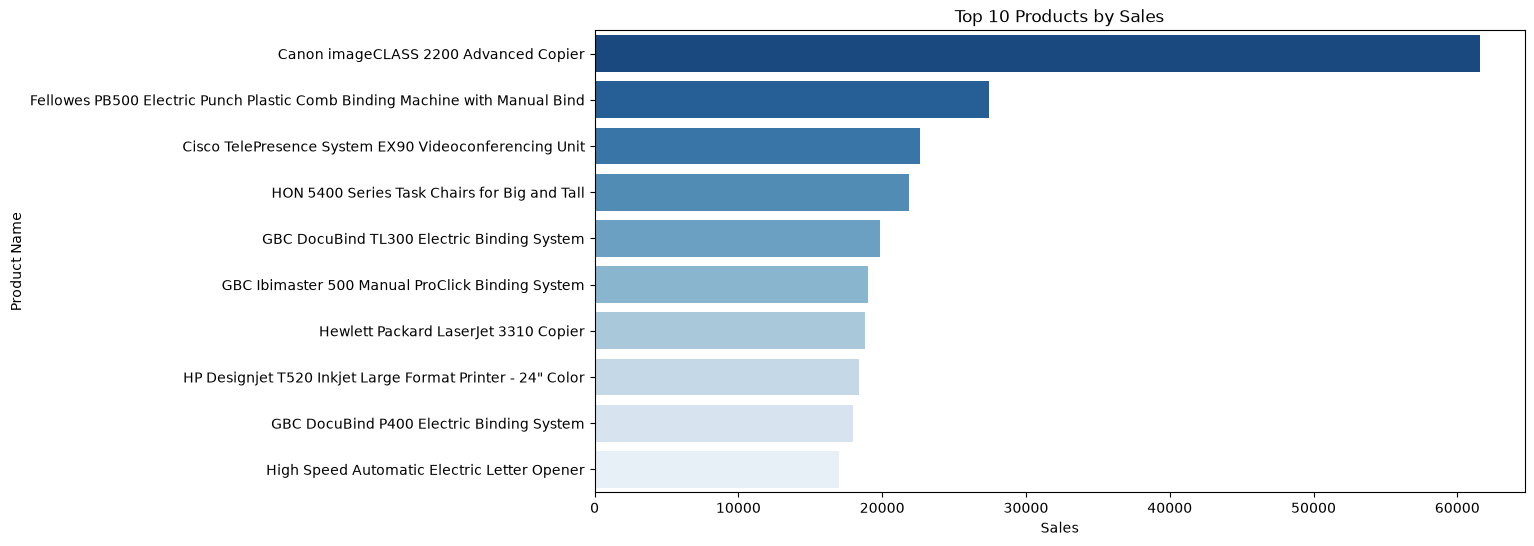

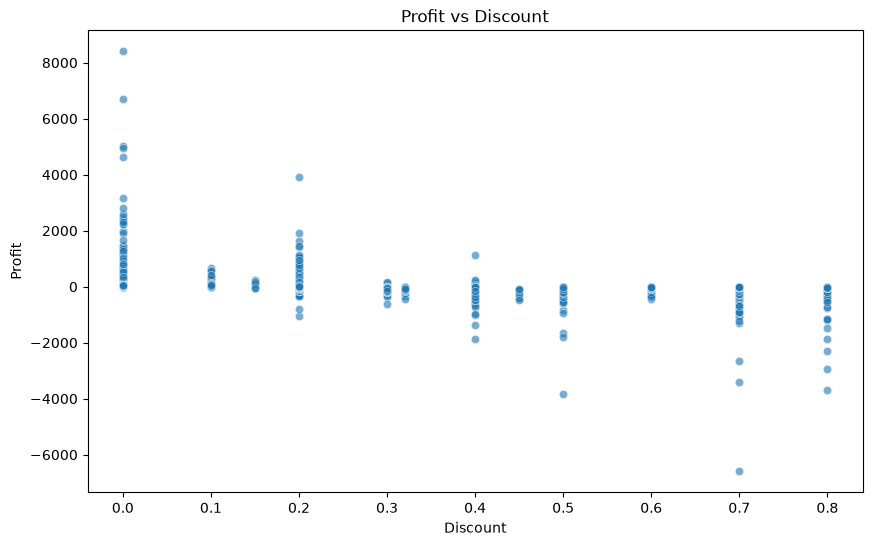


COMPARISON: MATPLOTLIB VS SEABORN

MATPLOTLIB
- Très flexible.
- Permet un contrôle détaillé des graphiques.
- Requiert généralement plus de code.

SEABORN
- Plus simple pour créer des graphiques élégants.
- Mieux adapté à l'exploration rapide des données.
- Offre une meilleure apparence par défaut.

CONCLUSION
- Matplotlib est idéal lorsque l'on souhaite personnaliser
  fortement un graphique.
- Seaborn est préférable pour produire rapidement des
  visualisations claires et professionnelles.



In [1]:
# ============================================================
# DAILY CHALLENGE : INTERACTIVE DATA VISUALIZATION
# ============================================================

# ------------------------------------------------------------
# 1. IMPORTER LES BIBLIOTHÈQUES
# ------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 2. CHARGER LE DATASET
# ------------------------------------------------------------
df = pd.read_excel("Superstore.xls", engine="xlrd")

# ------------------------------------------------------------
# 3. EXPLORER LES DONNÉES
# ------------------------------------------------------------
print("Premières lignes du dataset :")
print(df.head())

print("\nInformations sur les colonnes :")
print(df.info())

print("\nValeurs manquantes :")
print(df.isnull().sum())

# ------------------------------------------------------------
# 4. PRÉTRAITEMENT DES DONNÉES
# ------------------------------------------------------------
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Création d'une colonne Year pour l'analyse des ventes dans le temps
df['Year'] = df['Order Date'].dt.year

# ============================================================
# PARTIE MATPLOTLIB
# ============================================================

# ------------------------------------------------------------
# 5. CRÉER UN GRAPHIQUE EN LIGNES DES VENTES PAR ANNÉE
# ------------------------------------------------------------
sales_by_year = df.groupby('Year')['Sales'].sum()

plt.figure(figsize=(10,5))
plt.plot(
    sales_by_year.index,
    sales_by_year.values,
    marker='o',
    linewidth=2
)

plt.title('Sales Trends Over the Years')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# OBSERVATION :
# Ce graphique permet d'observer l'évolution des ventes
# d'une année à l'autre et d'identifier les tendances.
# ------------------------------------------------------------

# ------------------------------------------------------------
# 6. VISUALISER LA RÉPARTITION DES VENTES PAR PAYS
# ------------------------------------------------------------
country_sales = (
    df.groupby('Country')['Sales']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
country_sales.plot(kind='bar')
plt.title('Sales Distribution by Country')
plt.ylabel('Sales')
plt.show()

# ------------------------------------------------------------
# OBSERVATION :
# Dans le dataset Superstore, il est fréquent qu'il n'y ait
# qu'un seul pays (United States). Dans ce cas, le graphique
# comporte une seule barre.
# ------------------------------------------------------------

# ============================================================
# PARTIE SEABORN
# ============================================================

# ------------------------------------------------------------
# 7. TOP 10 PRODUITS PAR VENTES
# ------------------------------------------------------------
top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_products,
    x='Sales',
    y='Product Name',
    palette='Blues_r'
)

plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.ylabel('Product Name')
plt.show()

# ------------------------------------------------------------
# OBSERVATION :
# Ce graphique met en évidence les produits générant
# le chiffre d'affaires le plus élevé.
# ------------------------------------------------------------

# ------------------------------------------------------------
# 8. RELATION ENTRE PROFIT ET DISCOUNT
# ------------------------------------------------------------
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    alpha=0.6
)

plt.title('Profit vs Discount')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

# ------------------------------------------------------------
# OBSERVATION :
# Permet d'étudier l'effet des remises (Discount)
# sur le profit. On observe souvent qu'une remise élevée
# peut réduire le profit voire entraîner des pertes.
# ------------------------------------------------------------

# ============================================================
# ANALYSE COMPARATIVE
# ============================================================

print("\n================================================")
print("COMPARISON: MATPLOTLIB VS SEABORN")
print("================================================")

print("""
MATPLOTLIB
- Très flexible.
- Permet un contrôle détaillé des graphiques.
- Requiert généralement plus de code.

SEABORN
- Plus simple pour créer des graphiques élégants.
- Mieux adapté à l'exploration rapide des données.
- Offre une meilleure apparence par défaut.

CONCLUSION
- Matplotlib est idéal lorsque l'on souhaite personnaliser
  fortement un graphique.
- Seaborn est préférable pour produire rapidement des
  visualisations claires et professionnelles.
""")